In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Stimuli (space x time)
# -----------------------------
def moving_edge(x, t, v, x0=0.0, I_dark=0.0, I_bright=1.0):
    X, T = np.meshgrid(x, t, indexing="xy")
    edge_pos = x0 + v * T
    H = (X <= edge_pos).astype(float)  # NOTE: <= instead of >=
    stim = I_dark + (I_bright - I_dark) * H
    return stim.T
def drifting_grating(x, t, v, spatial_freq, contrast=1.0, phase_deg=0.0):
    """
    Drifting sinusoidal grating: cos(2π f (x - v t) + phase)
    spatial_freq in cycles / unit x.
    """
    phase = np.deg2rad(phase_deg)
    X, T = np.meshgrid(x, t, indexing="xy")
    stim = contrast * np.cos(2*np.pi*spatial_freq*(X - v*T) + phase)
    return stim.T  # (space, time)

def moving_bar(x, t, v, x0=0.0, bar_width=1.0, I_bg=0.0, I_bar=1.0):
    """
    Moving bar with constant width.
    Bar spans [x_left(t), x_right(t)] where x_left = x0 + v t and x_right = x_left + bar_width.
    Returns stim with I_bar inside the bar and I_bg elsewhere.
    Output: (space, time)
    """
    X, T = np.meshgrid(x, t, indexing="xy")
    x_left = x0 + v * T
    x_right = x_left + bar_width
    inside = (X >= x_left) & (X <= x_right)
    stim = np.where(inside, I_bar, I_bg).astype(float)
    return stim.T  # (space, time)



In [3]:
def fixed_delay(x, dt, delay_s, fill_value=0.0):
    """
    Pure time delay by delay_s seconds.
    y[t] = x[t - delay] (causal). Fills early samples with fill_value.
    """
    n = int(np.round(delay_s / dt))
    if n <= 0:
        return x.copy()
    y = np.empty_like(x, dtype=float)
    y[:n] = fill_value
    y[n:] = x[:-n]
    return y

In [4]:
## Define inputs, single moving edge
dt = 0.005      # 5 ms
T = 2.2
t = np.arange(0, T, dt)

dx = 0.05
x = np.arange(-5.0, 5.0+dx, dx)

# Two sample locations separated by delta_x
x1 = -0.5
delta_x = 0.5
x2 = x1 + delta_x

sigma_space = 0.4          # blur in x-units
sigma_pix = sigma_space / dx  # convert x-units -> pixels
tau_lp = 0.5
K_T = 1.0# seconds
do_highpass = True

##STIMS

stim_R = moving_bar(x, t, v=+3, x0=-3.0, bar_width=1.0, I_bg=0.0, I_bar=1.0)
stim_L = moving_bar(x, t, v=-3, x0=3.0, bar_width=1.0, I_bg=0.0, I_bar=1.0)

# spatial_freq = 0.2  # cycles per x-unit
# stim_R = drifting_grating(x, t, v=3.0, spatial_freq=spatial_freq, contrast=1.0, phase_deg=90.0)
# stim_L = drifting_grating(x, t, v=-3.0, spatial_freq=spatial_freq, contrast=1.0, phase_deg=90.0)



## Define detectors, just a gaussian blur of the pixels
stim_blur_R = gaussian_filter(
    stim_R.astype(float),
    sigma=(sigma_pix, 0.0),   # blur space only, no blur in time
    mode="nearest"
)

stim_blur_L = gaussian_filter(
    stim_L.astype(float),
    sigma=(sigma_pix, 0.0),   # blur space only, no blur in time
    mode="nearest"
)

# sample at PRs -1 and +1
x_prs = [-1.0, 0.0]
idx_prs = [np.argmin(np.abs(x - xp)) for xp in x_prs]
pr0_R = stim_blur_R[idx_prs[0], :]
pr1_R = stim_blur_R[idx_prs[1], :]

pr0_L = stim_blur_L[idx_prs[0], :]
pr1_L = stim_blur_L[idx_prs[1], :]

# def rc_lowpass(x, dt, tau):
#     a = dt / (tau + dt)
#     y = np.empty_like(x, dtype=float)
#     y[0] = x[0]
#     for i in range(1, len(x)):
#         y[i] = y[i-1] + a * (x[i] - y[i-1])
#     return y

# lp_pr0_R = rc_lowpass(pr0_R, dt, tau_lp)
# lp_pr0_L = rc_lowpass(pr0_L, dt, tau_lp)

delay_s = 0.2  # try 0.3, 0.5, 0.67

d_pr0_R = fixed_delay(pr0_R, dt, delay_s)
d_pr0_L = fixed_delay(pr0_L, dt, delay_s)


0.3029171134411862
0.3029004349303269


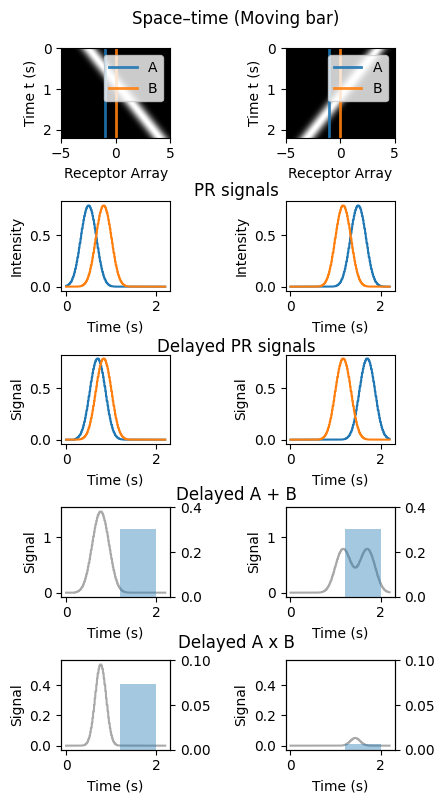

In [8]:
# --- plot PR signals + show where they are in the space-time image ---
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, axes = plt.subplots(5, 2, figsize=(3.5*1.3, 6*1.3))


axes[0,0].imshow(
    stim_blur_R.T, cmap="gray", aspect="auto",
    extent=[x[0], x[-1], t[-1], t[0]]
)
# axes[0,0].set_title("Space–time (blurred edge)")
axes[0,0].set_xlabel("Receptor Array")
axes[0,0].set_ylabel("Time t (s)")

axes[0,1].imshow(
    stim_blur_L.T, cmap="gray", aspect="auto",
    extent=[x[0], x[-1], t[-1], t[0]]
)
# axes[0,1].set_title("Space–time (blurred edge)")
axes[0,1].set_xlabel("Receptor Array")
axes[0,1].set_ylabel("Time t (s)")

labels =['A', 'B']
for j,(xp,l) in enumerate(zip(x_prs, labels)):
    c = colors[j % len(colors)]
    axes[0,0].axvline(xp,  c=c, linewidth=2, alpha=0.9, label=l)
    axes[0,1].axvline(xp,  c=c, linewidth=2, alpha=0.9, label=l)
axes[0,0].legend()
axes[0,1].legend()

axes[1,0].plot(t, pr0_R, label=f"A")
axes[1,0].plot(t, pr1_R, label=f"B")
# axes[1,0].set_title("Photoreceptor signals")
axes[1,0].set_xlabel("Time (s)")
axes[1,0].set_ylabel("Intensity")
# axes[1,0].legend()

axes[1,1].plot(t, pr0_L, label=f"A")
axes[1,1].plot(t, pr1_L, label=f"B")
# axes[1,1].set_title("Photoreceptor signals")
axes[1,1].set_xlabel("Time (s)")
axes[1,1].set_ylabel("Intensity")
# axes[1,1].legend()

##Lowpass
# axes[2,0].plot(t, lp_pr0_R, label=f"lpA")
axes[2,0].plot(t, d_pr0_R, label=f"delA")
axes[2,0].plot(t, pr1_R, label=f"B")
# axes[2,0].set_title("Photoreceptor signals")
axes[2,0].set_xlabel("Time (s)")
axes[2,0].set_ylabel("Signal")
# axes[2,0].legend()

# axes[2,1].plot(t, lp_pr0_L, label=f"lpA")
axes[2,1].plot(t, d_pr0_L, label=f"delA")
axes[2,1].plot(t, pr1_L, label=f"B")
# axes[2,1].set_title("Photoreceptor signals")
axes[2,1].set_xlabel("Time (s)")
axes[2,1].set_ylabel("Signal")
# axes[2,1].legend()

###################################################
## Linear comp
###################################################
axes[3,0].plot(t, d_pr0_R +pr1_R, label=f"delA + B", c='darkgray')
mean_hist = axes[3,0].twinx()
mean_hist.bar(1.6, np.mean(d_pr0_R +pr1_R), alpha=0.4)
print(np.mean(d_pr0_R +pr1_R))
axes[3,0].set_xlabel("Time (s)")
axes[3,0].set_ylabel("Signal")
mean_hist.set_ylim(0, 0.4)

axes[3,1].plot(t, d_pr0_L +pr1_L, label=f"delA + B", c='darkgray')
print(np.mean(d_pr0_L +pr1_L))
axes[3,1].set_xlabel("Time (s)")
axes[3,1].set_ylabel("Signal")
mean_hist_L = axes[3,1].twinx()
mean_hist_L.bar(1.6, np.mean(d_pr0_L +pr1_L), alpha=0.4)
mean_hist_L.set_ylim(0, 0.4)

###################################################
## Non Linear comp
###################################################
axes[4,0].plot(t, d_pr0_R*pr1_R, label=f"delA x B", c='darkgray')
axes[4,0].set_xlabel("Time (s)")
axes[4,0].set_ylabel("Signal")
mean_hist = axes[4,0].twinx()
mean_hist.bar(1.6, np.mean(d_pr0_R *pr1_R), alpha=0.4)
mean_hist.set_ylim(0,0.1)


axes[4,1].plot(t, d_pr0_L*pr1_L, label=f"delA x B", c='darkgray')
axes[4,1].set_xlabel("Time (s)")
axes[4,1].set_ylabel("Signal")
mean_hist_L = axes[4,1].twinx()
mean_hist_L.bar(1.6, np.mean(d_pr0_L * pr1_L), alpha=0.4)
mean_hist_L.set_ylim(0,0.1)


###################################################
## Tittles
###################################################
fig.text(0.53, 1.0, "Space–time (Moving bar)",  ha="center", va="bottom", fontsize=12)
fig.text(0.53, 0.78, "PR signals",  ha="center", va="bottom", fontsize=12)
fig.text(0.53, 0.58, "Delayed PR signals",  ha="center", va="bottom", fontsize=12)
fig.text(0.53, 0.39, "Delayed A + B",  ha="center", va="bottom", fontsize=12)
fig.text(0.53, 0.2, "Delayed A x B",  ha="center", va="bottom", fontsize=12)
plt.tight_layout()

def set_row_ylim(axes_row, ymins, ymaxs, pad=0.05):
    """Set same ylim for a pair of axes (L,R) based on provided mins/maxs."""
    y0 = float(np.min(ymins))
    y1 = float(np.max(ymaxs))
    rng = y1 - y0
    if rng == 0:
        rng = 1.0
    y0 -= pad * rng
    y1 += pad * rng
    for ax in axes_row:
        ax.set_ylim(y0, y1)
    return (y0, y1)

# ---- Row 1: PR signals (axes[1,0] and axes[1,1]) ----
ymins = [pr0_R.min(), pr1_R.min(), pr0_L.min(), pr1_L.min()]
ymaxs = [pr0_R.max(), pr1_R.max(), pr0_L.max(), pr1_L.max()]
set_row_ylim(axes[1, :], ymins, ymaxs)

# ---- Row 2: Delayed vs B (axes[2,0] and axes[2,1]) ----
ymins = [d_pr0_R.min(), pr1_R.min(), d_pr0_L.min(), pr1_L.min()]
ymaxs = [d_pr0_R.max(), pr1_R.max(), d_pr0_L.max(), pr1_L.max()]
set_row_ylim(axes[2, :], ymins, ymaxs)

# ---- Row 3: Linear (delA + B) ----
lin_R = d_pr0_R + pr1_R
lin_L = d_pr0_L + pr1_L
set_row_ylim(axes[3, :], [lin_R.min(), lin_L.min()], [lin_R.max(), lin_L.max()])

# ---- Row 4: Nonlinear (delA * B) ----
nl_R = d_pr0_R * pr1_R
nl_L = d_pr0_L * pr1_L
set_row_ylim(axes[4, :], [nl_R.min(), nl_L.min()], [nl_R.max(), nl_L.max()])


plt.show()


## Misc

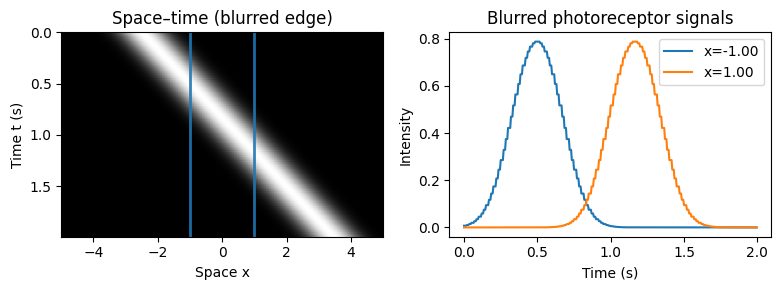

In [14]:
sigma_pix = sigma_space / dx  # convert x-units -> pixels

stim_blur = gaussian_filter(
    stim.astype(float),
    sigma=(sigma_pix, 0.0),   # blur space only, no blur in time
    mode="nearest"
)

# sample at PRs -1 and +1
x_prs = [-1.0, 1.0]
idx_prs = [np.argmin(np.abs(x - xp)) for xp in x_prs]
pr0 = stim_blur[idx_prs[0], :]
pr1 = stim_blur[idx_prs[1], :]

# --- plot PR signals + show where they are in the space-time image ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(
    stim_blur.T, cmap="gray", aspect="auto",
    extent=[x[0], x[-1], t[-1], t[0]]
)
axes[0].set_title("Space–time (blurred edge)")
axes[0].set_xlabel("Space x")
axes[0].set_ylabel("Time t (s)")
for xp in x_prs:
    axes[0].axvline(xp, linewidth=2, alpha=0.9)

axes[1].plot(t, pr0, label=f"x={x[idx_prs[0]]:.2f}")
axes[1].plot(t, pr1, label=f"x={x[idx_prs[1]]:.2f}")
axes[1].set_title("Blurred photoreceptor signals")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Intensity")
axes[1].legend()

plt.tight_layout()
plt.show()



/tmp/ipykernel_28211/1769253624.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper right')


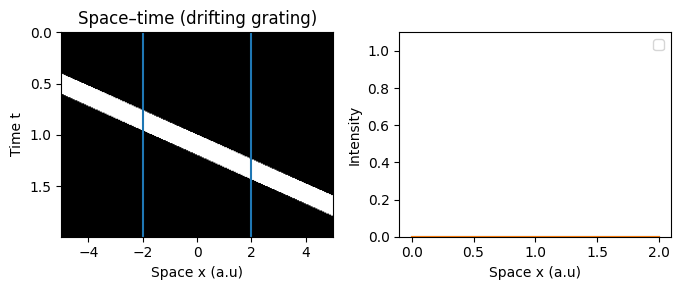

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7,3))

# Space-time image
im = axes[0].imshow(
    stim, cmap="gray", aspect="auto",
    extent=[x[0], x[-1], t[-1], t[0]]  # x on horizontal, time increases downward->upward fix
)
axes[0].set_title("Space–time (drifting grating)")
axes[0].set_xlabel("Space x (a.u)")
axes[0].set_ylabel("Time t")

# Spatial snapshots at a few times (choose indices from your t vector!)
# Ts = [0.1, .5, 1]  # seconds
prs  = [-2,2] 
# for Tsec in Ts:
#     Ti = int(round(Tsec / dt))
#     axes[1].plot(x, stim[:, Ti], label=f'T={Tsec}')
#     axes[0].axhline(Tsec)
for pr in prs:
    axes[1].plot(t, stim[pr, :])
    axes[0].axvline(pr)
    
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Space x (a.u)")
axes[1].set_ylim(stim.min()*1.1, stim.max()*1.1)
axes[1].legend(loc='upper right')

fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

def save_grating_line_gif(stim, x, t, out_path="drifting_grating_line.gif",
                          max_frames=200, fps=30):
    """
    stim: (space, time)
    Makes a GIF where each frame is a line plot stim[:, k] vs x.
    """
    nT = stim.shape[1]
    n_frames = min(nT, max_frames)
    frame_idxs = np.linspace(0, nT-1, n_frames).astype(int)

    ymin, ymax = stim.min(), stim.max()

    frames = []
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
    (ln,) = ax.plot(x, stim[:, frame_idxs[0]])
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(ymin*1.05, ymax*1.05)
    ax.set_xlabel("Space x")
    ax.set_ylabel("Contrast")
    title = ax.set_title("")

    for k in frame_idxs:
        ln.set_ydata(stim[:, k])
        title.set_text(f"t = {t[k]:.3f} s")
        fig.canvas.draw()
        rgb = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(rgb)

    plt.close(fig)
    imageio.mimsave(out_path, frames, duration=1.0/fps)
    return out_path
save_grating_line_gif(stim, x, t)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

def save_grating_strip_gif(stim, x, t, out_path="drifting_grating_strip.gif",
                           max_frames=200, fps=30, strip_height=60):
    """
    stim: (space, time)
    Each frame is a thin image: repeated stim[:,k] as rows.
    """
    nT = stim.shape[1]
    n_frames = min(nT, max_frames)
    frame_idxs = np.linspace(0, nT-1, n_frames).astype(int)

    vmin, vmax = stim.min(), stim.max()

    frames = []
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

    frame0 = np.tile(stim[:, frame_idxs[0]][None, :], (strip_height, 1))
    im = ax.imshow(frame0, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax,
                   extent=[x[0], x[-1], 0, 1], origin="lower")
    ax.set_yticks([])
    ax.set_xlabel("Space x")
    title = ax.set_title("")

    for k in frame_idxs:
        frame = np.tile(stim[:, k][None, :], (strip_height, 1))
        im.set_data(frame)
        title.set_text(f"t = {t[k]:.3f} s")
        fig.canvas.draw()
        rgb = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(rgb)

    plt.close(fig)
    imageio.mimsave(out_path, frames, duration=1.0/fps)
    return out_path
save_grating_strip_gif(stim, x, t)



In [45]:
def exp_lowpass(dt, tau, T=0.5):
    """Causal exponential low-pass kernel, length ~T seconds."""
    n = int(np.ceil(T / dt))
    t = np.arange(n) * dt
    k = np.exp(-t / tau)
    k /= (k.sum() + 1e-12)  # normalize DC gain to 1
    return k


In [ ]:
def causal_filter(x_t, k):
    """Causal convolution along time axis for 1D signal x_t."""
    # fftconvolve gives full; we keep causal part aligned to t
    y = fftconvolve(x_t, k, mode="full")[: len(x_t)]
    return y

# -----------------------------
# Stimuli (space x time)
# -----------------------------
def moving_edge(x, t, v, x0=0.0, contrast=1.0, polarity=1.0):
    """
    Moving step edge: I(x,t) = polarity*contrast*H(x - (x0 + v t))
    polarity=+1: dark->bright step; -1 flips.
    """
    X, T = np.meshgrid(x, t, indexing="xy")
    edge_pos = x0 + v * T
    stim = (X >= edge_pos).astype(float)
    stim = polarity * contrast * (stim - 0.5) * 2.0  # centered roughly in [-contrast, +contrast]
    return stim.T  # (space, time)

def drifting_grating(x, t, v, spatial_freq, contrast=1.0, phase_deg=0.0):
    """
    Drifting sinusoidal grating: cos(2π f (x - v t) + phase)
    spatial_freq in cycles / unit x.
    """
    phase = np.deg2rad(phase_deg)
    X, T = np.meshgrid(x, t, indexing="xy")
    stim = contrast * np.cos(2*np.pi*spatial_freq*(X - v*T) + phase)
    return stim.T  # (space, time)

# -----------------------------
# Spatial sampling / photoreceptors
# -----------------------------
def photoreceptor_signals(stim_xt, x, x1, x2, sigma_space=0.5):
    """
    stim_xt: (space, time).
    Apply Gaussian blur over space and read out at x1,x2 (nearest index).
    """
    blurred = gaussian_filter1d(stim_xt, sigma=sigma_space / (x[1]-x[0]), axis=0, mode="nearest")
    i1 = np.argmin(np.abs(x - x1))
    i2 = np.argmin(np.abs(x - x2))
    s1 = blurred[i1, :]
    s2 = blurred[i2, :]
    return s1, s2